Fetching / loading APASS reference catalog...
1839 APASS reference stars in field
Looking in: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\cutouts
Directory exists: True
1475 plates found
100/1475  elapsed 121.1s
200/1475  elapsed 204.1s
300/1475  elapsed 284.3s
400/1475  elapsed 382.8s
500/1475  elapsed 533.8s
600/1475  elapsed 641.8s
700/1475  elapsed 769.6s
800/1475  elapsed 865.0s
900/1475  elapsed 950.1s
1000/1475  elapsed 1030.6s
1100/1475  elapsed 1110.7s
1200/1475  elapsed 1181.8s
1300/1475  elapsed 1256.4s
1400/1475  elapsed 1336.1s
rejection_reason
NaN                                       1396
too few matched ref stars                   35
target flux non-positive (below noise)      30
target below detection SNR threshold        14
Name: count, dtype: int64
1396/1475 plates passed quality gates
Median magcal_local_err: 0.7966360000073084

Global RMS distribution among passing plates:
count    1396.000000
mean        0.791085
std         0.

Rejecting standard AFLAGS ...
Assigned rejection tag `aflags` to bit number 1
Marked 311 new rows as rejected; 311 total are rejected

After rejections, 1507 non-rejected detections remain.


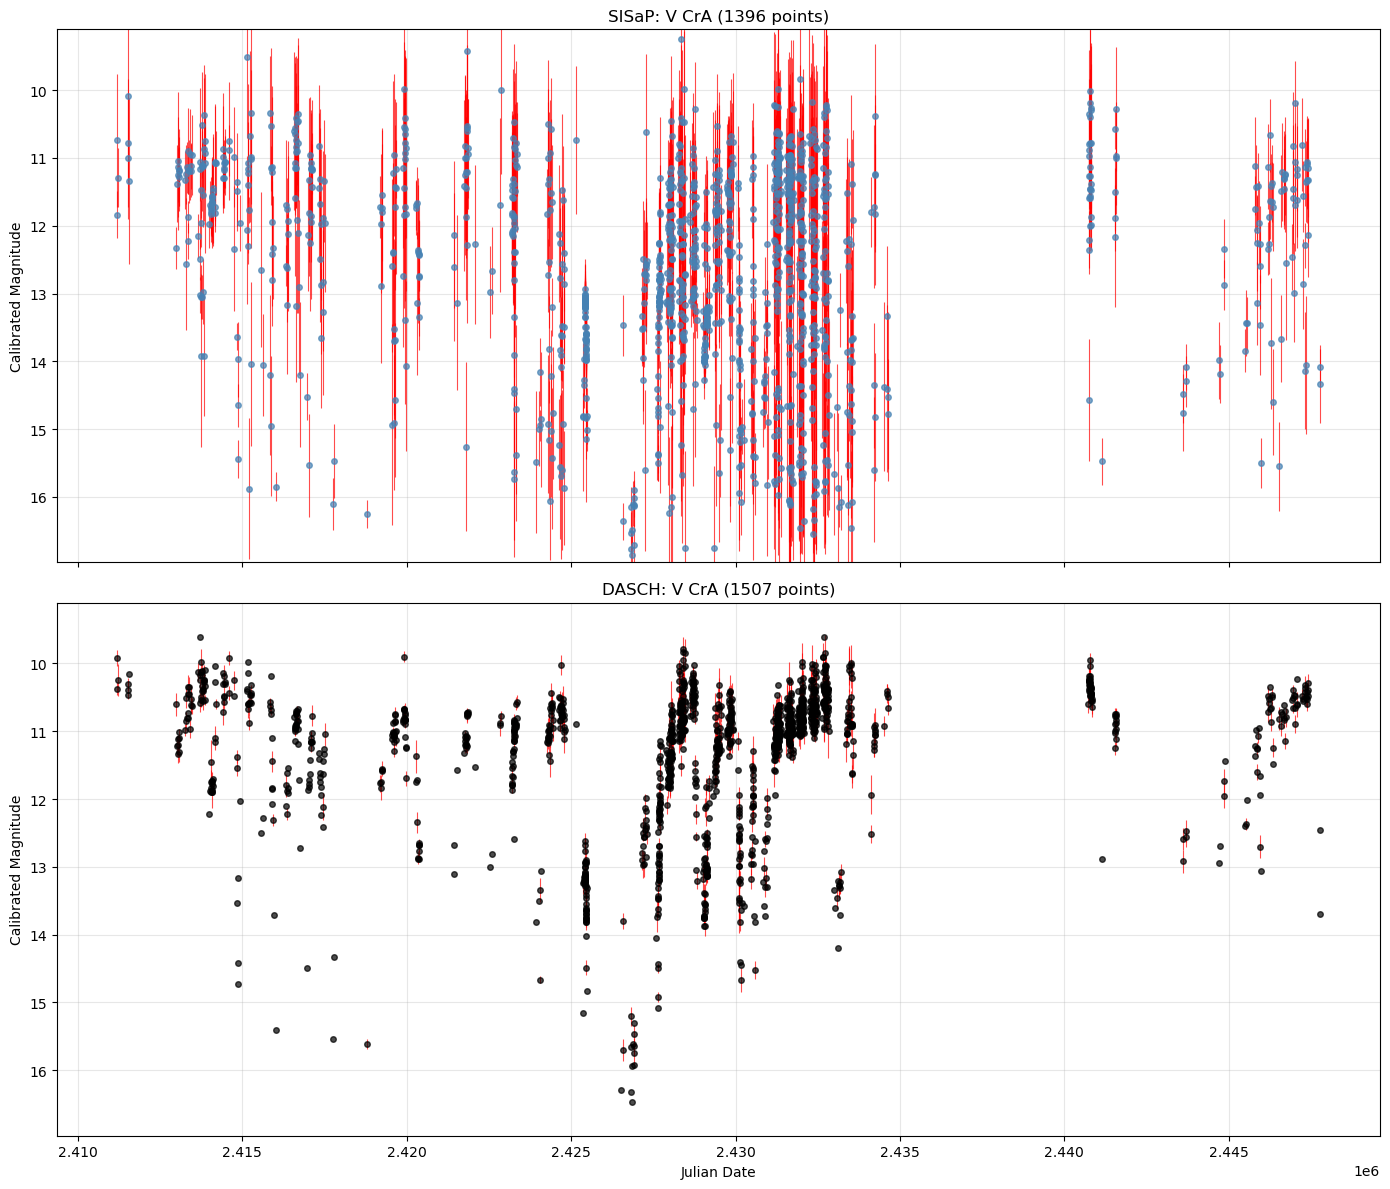

In [1]:
# DASCH-replica photometry pipeline for V CrA cutouts, plus comparison
# against the official DASCH archive light curve.
# Requires: astropy, sep-pjw, scipy, pandas, matplotlib, astroquery, daschlab
# Optional: statsmodels (better LOWESS; a fallback is used if not installed)

import os, glob, math, time, re, warnings
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
import sep
from scipy import stats
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as _sm_lowess
    def lowess_fit(x, y, frac=0.3):
        out = _sm_lowess(y, x, frac=frac, return_sorted=True)
        return out[:, 0], out[:, 1]
except ImportError:
    def lowess_fit(x, y, frac=0.3):
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        n = len(xs)
        span = max(int(frac * n), 4)
        fitted = np.empty(n)
        for i in range(n):
            lo = max(0, min(i - span // 2, n - span))
            hi = min(n, lo + span)
            xw, yw = xs[lo:hi], ys[lo:hi]
            if len(xw) < 2 or np.ptp(xw) == 0:
                fitted[i] = np.median(yw)
            else:
                slope, intercept, *_ = stats.linregress(xw, yw)
                fitted[i] = slope * xs[i] + intercept
        return xs, fitted

# ---------------------------------------------------------------------------
# Paths / target
# ---------------------------------------------------------------------------
VCRA_RA_DEG  = 281.884623417
VCRA_DEC_DEG = -38.158974417

CUTOUT_DIR = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\cutouts"
V_CRA_DIR  = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA"
OUTPUT_DIR = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\02_C_DASCH_Replica"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# DASCH.config equivalent (production SExtractor settings)
# ---------------------------------------------------------------------------
DETECT_THRESH    = 1.5
DETECT_MINAREA   = 5
DEBLEND_NTHRESH  = 32
DEBLEND_MINCONT  = 0.005
APER_ARCSEC      = 10.0
ANNULUS_GAP_PX   = 3
ANNULUS_THICK_PX = 20
SATUR_LEVEL      = 32000.0

# ---------------------------------------------------------------------------
# Calibration parameters
# ---------------------------------------------------------------------------
MATCH_RADIUS_ARCSEC        = 10.0
MATCH_RADIUS_WIDE_ARCSEC   = 25.0
MIN_REF_STARS_GLOBAL       = 25
MIN_REF_STARS_ABSOLUTE_MIN = 20
NBINS_LOCAL          = 9
MIN_REF_STARS_LOCAL  = 8
SIGNIF_THRESHOLD     = 5.0
OUTLIER_SIGMA        = 3.0
EXTRAP_MARGIN_MAG    = 10.0
MAX_CALIBRATION_RMS  = 2.5   # loose sanity ceiling only -- catches genuinely broken
                              # fits (e.g. the earlier double-background-subtraction
                              # bug), not a precision bar. On these small cutouts a
                              # global fit of 0.5-1.5 mag RMS is normal; the local
                              # bin correction below is what actually tightens it,
                              # matching DASCH's real two-stage global+local design
COLOR_TERM_MIN_STARS  = 30
COLOR_TERM_SANITY_MAX = 2.5
REF_COLOR_BLUE       = 'Bmag'
REF_COLOR_RED        = 'Vmag'
REF_BANDS            = ['Bmag', 'Vmag']

# ---------------------------------------------------------------------------
# 1. Fetch APASS reference catalog once for the whole field (cached to disk)
# ---------------------------------------------------------------------------
CATALOG_CACHE = os.path.join(OUTPUT_DIR, 'apass_field.csv')

def fetch_apass_catalog(ra, dec, radius_arcmin=25.0):
    if os.path.exists(CATALOG_CACHE):
        return pd.read_csv(CATALOG_CACHE)
    from astroquery.vizier import Vizier
    Vizier.ROW_LIMIT = -1
    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    result = Vizier.query_region(coord, radius=radius_arcmin * u.arcmin, catalog='II/336/apass9')
    if len(result) == 0:
        raise RuntimeError('APASS query returned no results for this field')
    tbl = result[0].to_pandas()
    tbl = tbl.rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'})
    tbl = tbl.dropna(subset=[REF_COLOR_BLUE, REF_COLOR_RED]).reset_index(drop=True)
    tbl.to_csv(CATALOG_CACHE, index=False)
    return tbl

print('Fetching / loading APASS reference catalog...')
apass = fetch_apass_catalog(VCRA_RA_DEG, VCRA_DEC_DEG)
apass['color'] = apass[REF_COLOR_BLUE] - apass[REF_COLOR_RED]
print(f'{len(apass)} APASS reference stars in field')

# ---------------------------------------------------------------------------
# 2. Detection + aperture photometry (SExtractor-equivalent, via sep)
# ---------------------------------------------------------------------------
def measure_aperture(data_sub, data_raw, x, y, pixel_scale_arcsec, err):
    aper_px  = APER_ARCSEC / pixel_scale_arcsec
    r_in_px  = aper_px + ANNULUS_GAP_PX
    r_out_px = r_in_px + ANNULUS_THICK_PX

    flux, fluxerr, flag = sep.sum_circle(data_sub, x, y, aper_px, err=err, gain=1.0)
    bkg_flux, _, _ = sep.sum_circann(data_sub, x, y, r_in_px, r_out_px, err=err)
    annulus_area = math.pi * (r_out_px ** 2 - r_in_px ** 2)
    aper_area    = math.pi * aper_px ** 2
    flux_localbkg = flux - (bkg_flux / annulus_area) * aper_area

    yy = np.clip(np.round(np.atleast_1d(y)).astype(int), 0, data_raw.shape[0] - 1)
    xx = np.clip(np.round(np.atleast_1d(x)).astype(int), 0, data_raw.shape[1] - 1)
    peak = data_raw[yy, xx]

    return flux_localbkg, fluxerr, flag, peak, aper_px

def detect_and_measure(data, pixel_scale_arcsec):
    data = data.astype(np.float64)
    bkg = sep.Background(data)
    data_sub = data - bkg.back()
    objects = sep.extract(
        data_sub, DETECT_THRESH, err=bkg.globalrms,
        minarea=DETECT_MINAREA,
        deblend_nthresh=DEBLEND_NTHRESH, deblend_cont=DEBLEND_MINCONT,
        clean=False,
    )
    if len(objects) == 0:
        return None, data_sub, bkg

    flux, fluxerr, flag, peak, aper_px = measure_aperture(
        data_sub, data, objects['x'], objects['y'], pixel_scale_arcsec, bkg.globalrms,
    )

    tbl = pd.DataFrame({
        'x': objects['x'], 'y': objects['y'],
        'flux': flux, 'fluxerr': fluxerr,
        'flag': flag, 'peak': peak,
        'a': objects['a'], 'b': objects['b'], 'theta': objects['theta'],
        'ellipticity': 1.0 - objects['b'] / objects['a'],
    })
    tbl['saturated'] = tbl['peak'] >= SATUR_LEVEL
    tbl = tbl[tbl['flux'] > 0].reset_index(drop=True)
    tbl['mag_inst'] = -2.5 * np.log10(tbl['flux'])
    tbl['mag_inst_err'] = 1.0857 * tbl['fluxerr'] / tbl['flux']
    tbl['snr'] = tbl['flux'] / tbl['fluxerr']
    return tbl, data_sub, bkg

def forced_photometry_at(data_sub, data_raw, x, y, pixel_scale_arcsec, err):
    flux, fluxerr, flag, peak, aper_px = measure_aperture(
        data_sub, data_raw, np.array([x]), np.array([y]), pixel_scale_arcsec, err,
    )
    flux, fluxerr, flag, peak = float(flux[0]), float(fluxerr[0]), int(flag[0]), float(peak[0])
    if flux <= 0 or fluxerr <= 0:
        return None
    return {
        'x': x, 'y': y, 'flux': flux, 'fluxerr': fluxerr, 'flag': flag, 'peak': peak,
        'saturated': peak >= SATUR_LEVEL,
        'mag_inst': -2.5 * np.log10(flux),
        'mag_inst_err': 1.0857 * fluxerr / flux,
        'snr': flux / fluxerr,
    }

# ---------------------------------------------------------------------------
# 3. Bisector linear regression (Isobe et al. 1990), ported from xcolorterm.m
# ---------------------------------------------------------------------------
def bisector_fit(x, y):
    xm, ym = np.mean(x), np.mean(y)
    Sxx = np.sum((x - xm) ** 2)
    Syy = np.sum((y - ym) ** 2)
    Sxy = np.sum((x - xm) * (y - ym))
    if Sxy == 0 or Sxx == 0:
        return 0.0
    beta1 = Sxy / Sxx
    beta2 = Syy / Sxy
    beta3 = (beta1 * beta2 - 1 + ((1 + beta1 ** 2) * (1 + beta2 ** 2)) ** 0.5) / (beta1 + beta2)
    return beta3

# ---------------------------------------------------------------------------
# 4. Iterative sigma-clipped global calibration curve
# ---------------------------------------------------------------------------
def adaptive_frac(n):
    return float(np.clip(20.0 / max(n, 1), 0.2, 0.6))

def robust_global_calibration(inst_mag, ref_mag, color):
    order = np.argsort(inst_mag)
    m, r, c = inst_mag[order], ref_mag[order], color[order]
    frac = adaptive_frac(len(m))
    xs, fitted = lowess_fit(m, r, frac=frac)
    resid = r - np.interp(m, xs, fitted)

    for sigma in (OUTLIER_SIGMA, OUTLIER_SIGMA, 4.0):
        rms = np.std(resid)
        keep = np.abs(resid) < sigma * rms
        if keep.sum() < MIN_REF_STARS_ABSOLUTE_MIN:
            break
        m, r, c, resid = m[keep], r[keep], c[keep], resid[keep]
        frac = adaptive_frac(len(m))
        xs, fitted = lowess_fit(m, r, frac=frac)
        resid = r - np.interp(m, xs, fitted)

    cterm = 0.0
    xs2, fitted2, resid2 = xs, fitted, resid
    if len(m) >= COLOR_TERM_MIN_STARS:
        trial_cterm = bisector_fit(c, resid)
        if abs(trial_cterm) <= COLOR_TERM_SANITY_MAX:
            r_corr = r - c * trial_cterm
            frac2 = adaptive_frac(len(m))
            xs2t, fitted2t = lowess_fit(m, r_corr, frac=frac2)
            resid2t = r_corr - np.interp(m, xs2t, fitted2t)
            if np.std(resid2t) < np.std(resid):
                cterm, xs2, fitted2, resid2 = trial_cterm, xs2t, fitted2t, resid2t

    return {
        'inst_mag': m, 'curve_x': xs2, 'curve_y': fitted2,
        'colorterm': cterm, 'rms': float(np.std(resid2)), 'n': len(m),
    }

def invert_calibration(cal, inst_mag_target):
    lo, hi = cal['curve_x'].min(), cal['curve_x'].max()
    if lo - EXTRAP_MARGIN_MAG <= inst_mag_target <= hi + EXTRAP_MARGIN_MAG:
        return float(np.interp(inst_mag_target, cal['curve_x'], cal['curve_y']))
    return None

# ---------------------------------------------------------------------------
# 5. Radial 9-bin local calibration. Now also returns the local-bin RMS --
#    this is the number that actually matters, matching DASCH's own
#    magcal_local_rms field.
# ---------------------------------------------------------------------------
def assign_radial_bin(x, y, width, height, nbins=NBINS_LOCAL):
    cx, cy = width / 2.0, height / 2.0
    rmax = math.hypot(cx, cy)
    r = np.hypot(x - cx, y - cy)
    return np.clip((r / rmax * nbins).astype(int) + 1, 1, nbins)

def local_correction(bins, residual, target_bin):
    sel = bins == target_bin
    if sel.sum() < MIN_REF_STARS_LOCAL:
        return 0.0, 0, np.nan
    vals = residual[sel]
    for _ in range(3):
        med, rms = np.median(vals), np.std(vals)
        keep = np.abs(vals - med) < OUTLIER_SIGMA * rms
        if keep.sum() < 3:
            break
        vals = vals[keep]
    local_rms = float(np.std(vals)) if len(vals) > 1 else np.nan
    return float(np.median(vals)), len(vals), local_rms

# ---------------------------------------------------------------------------
# 6. Per-plate pipeline
# ---------------------------------------------------------------------------
def process_plate(fits_path, apass):
    with fits.open(fits_path) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        wcs = WCS(header)
        if not wcs.has_celestial:
            return {'file': os.path.basename(fits_path), 'quality_ok': False,
                    'rejection_reason': 'no WCS'}

    height, width = data.shape
    scale_deg = np.mean(np.abs(wcs.pixel_scale_matrix.diagonal()))
    pixel_scale_arcsec = scale_deg * 3600.0

    date = None
    for key in ('DATE-OBS', 'DATE-AVG', 'MJD-OBS'):
        if key in header:
            try:
                date = Time(header[key]).jd
                break
            except Exception:
                pass

    detections, data_sub, bkg = detect_and_measure(data, pixel_scale_arcsec)
    if detections is None or len(detections) < MIN_REF_STARS_ABSOLUTE_MIN:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'too few detections'}

    ra, dec = wcs.all_pix2world(detections['x'], detections['y'], 0)
    detections['ra'], detections['dec'] = ra, dec

    det_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    ref_coords = SkyCoord(ra=apass['ra'].values * u.deg, dec=apass['dec'].values * u.deg)
    idx, sep2d, _ = det_coords.match_to_catalog_sky(ref_coords)

    matched = sep2d.arcsec < MATCH_RADIUS_ARCSEC
    match_radius_used = MATCH_RADIUS_ARCSEC
    if matched.sum() < MIN_REF_STARS_GLOBAL:
        matched = sep2d.arcsec < MATCH_RADIUS_WIDE_ARCSEC
        match_radius_used = MATCH_RADIUS_WIDE_ARCSEC

    ref_df = apass.iloc[idx[matched]].reset_index(drop=True)
    det_df = detections[matched].reset_index(drop=True)
    good = (
        (~det_df['saturated']) &
        (det_df['flag'] == 0) &
        (det_df['snr'] > SIGNIF_THRESHOLD) &
        (det_df['ellipticity'] < 0.5)
    )
    ref_df, det_df = ref_df[good].reset_index(drop=True), det_df[good].reset_index(drop=True)

    if len(det_df) < MIN_REF_STARS_ABSOLUTE_MIN:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'too few matched ref stars',
                'match_radius_used': match_radius_used}

    cal = None
    for band in REF_BANDS:
        trial = robust_global_calibration(
            det_df['mag_inst'].values, ref_df[band].values, ref_df['color'].values,
        )
        if cal is None or trial['rms'] < cal['rms']:
            cal = trial
            cal['band'] = band

    if cal['rms'] > MAX_CALIBRATION_RMS:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'calibration RMS too high (broken fit)',
                'global_rms': cal['rms'], 'n_ref_global': cal['n']}

    curve_pred = np.interp(det_df['mag_inst'].values, cal['curve_x'], cal['curve_y'])
    ref_corr = ref_df[cal['band']].values - ref_df['color'].values * cal['colorterm']
    residual = ref_corr - curve_pred

    bins = assign_radial_bin(det_df['x'].values, det_df['y'].values, width, height)

    tx, ty = wcs.all_world2pix(VCRA_RA_DEG, VCRA_DEC_DEG, 0)
    if not (0 <= tx < width and 0 <= ty < height):
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'target position outside cutout'}

    target = forced_photometry_at(data_sub, data, tx, ty, pixel_scale_arcsec, bkg.globalrms)
    if target is None:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'target flux non-positive (below noise)'}
    if target['snr'] < SIGNIF_THRESHOLD:
        limiting_mag = float(np.percentile(ref_corr, 95)) if cal['n'] else np.nan
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'target below detection SNR threshold',
                'limiting_mag_local': limiting_mag}

    global_mag = invert_calibration(cal, target['mag_inst'])
    if global_mag is None:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'instrumental mag outside calibrated range'}

    target_bin = assign_radial_bin(np.array([tx]), np.array([ty]), width, height)[0]
    local_corr, n_local, local_rms = local_correction(bins, residual, target_bin)
    magcal_local = global_mag + local_corr

    # local RMS is the real per-point precision when the bin has enough stars
    # to trust it; otherwise fall back to the (looser) global fit RMS
    calib_err_component = local_rms if (n_local >= MIN_REF_STARS_LOCAL and not np.isnan(local_rms)) else cal['rms']
    magcal_local_err = float(np.hypot(target['mag_inst_err'], calib_err_component))

    return {
        'file': os.path.basename(fits_path), 'date_jd': date,
        'quality_ok': True,
        'x': tx, 'y': ty, 'spatial_bin': int(target_bin),
        'mag_inst': target['mag_inst'], 'snr': target['snr'],
        'ref_band': cal['band'], 'match_radius_used': match_radius_used,
        'magcal_global': global_mag, 'magcal_local': magcal_local,
        'magcal_local_err': magcal_local_err,
        'colorterm': cal['colorterm'], 'global_rms': cal['rms'], 'local_rms': local_rms,
        'n_ref_global': cal['n'], 'n_ref_local': n_local,
        'flag': target['flag'], 'saturated': bool(target['saturated']),
    }

# ---------------------------------------------------------------------------
# 7. Run over all cutouts
# ---------------------------------------------------------------------------
print('Looking in:', CUTOUT_DIR)
print('Directory exists:', os.path.isdir(CUTOUT_DIR))

fits_files = sorted(
    glob.glob(os.path.join(CUTOUT_DIR, '*.fits')) +
    glob.glob(os.path.join(CUTOUT_DIR, '*.fit'))
)
print(f'{len(fits_files)} plates found')

if len(fits_files) == 0:
    if os.path.isdir(CUTOUT_DIR):
        print('Directory exists but no .fits/.fit files matched. Contents:')
        for f in os.listdir(CUTOUT_DIR)[:20]:
            print(' ', f)
    raise SystemExit('No FITS files found -- fix CUTOUT_DIR or the glob pattern above before continuing.')

results = []
t0 = time.time()
for i, f in enumerate(fits_files):
    try:
        r = process_plate(f, apass)
    except Exception as e:
        r = {'file': os.path.basename(f), 'quality_ok': False, 'rejection_reason': f'error: {e}'}
    results.append(r)
    if (i + 1) % 100 == 0:
        print(f'{i + 1}/{len(fits_files)}  elapsed {time.time() - t0:.1f}s')

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'vcra_dasch_replica_results.csv'), index=False)
print(results_df['rejection_reason'].value_counts(dropna=False))

lightcurve = results_df[results_df['quality_ok']].copy()
lightcurve.to_csv(os.path.join(OUTPUT_DIR, 'vcra_dasch_replica_lightcurve.csv'), index=False)
print(f"{len(lightcurve)}/{len(results_df)} plates passed quality gates")
print('Median magcal_local_err:', lightcurve['magcal_local_err'].median())
print('\nGlobal RMS distribution among passing plates:')
print(lightcurve['global_rms'].describe())
print('\nLocal-bin RMS distribution among passing plates:')
print(lightcurve['local_rms'].describe())

# ---------------------------------------------------------------------------
# 8. Pull the official DASCH archive light curve
# ---------------------------------------------------------------------------
import daschlab

sess = daschlab.Session(V_CRA_DIR)
sess.select_target(name='V CrA')
sess.select_refcat('apass')
lc = sess.lightcurve(0)
lc.apply_standard_rejections()
dasch_df = lc.to_pandas()
dasch_df['time_jd'] = lc['time'].jd
dasch_df.to_csv(os.path.join(V_CRA_DIR, 'dasch_official_lightcurve.csv'), index=False)
dasch_good = dasch_df[(dasch_df['reject'] == 0) & (dasch_df['magcal_magdep'].notna())]

# ---------------------------------------------------------------------------
# 9. Stacked two-panel comparison
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, sharey=True)

ax1.errorbar(lightcurve['date_jd'], lightcurve['magcal_local'],
             yerr=lightcurve['magcal_local_err'],
             fmt='o', ms=4, alpha=0.7, color='steelblue',
             ecolor='red', elinewidth=0.8, capsize=0)
ax1.set_title(f'SISaP: V CrA ({len(lightcurve)} points)')
ax1.set_ylabel('Calibrated Magnitude')
ax1.grid(alpha=0.3)

ax2.errorbar(dasch_good['time_jd'], dasch_good['magcal_magdep'],
             yerr=dasch_good['magcal_magdep_rms'],
             fmt='o', ms=4, alpha=0.7, color='black',
             ecolor='red', elinewidth=0.8, capsize=0)
ax2.set_title(f'DASCH: V CrA ({len(dasch_good)} points)')
ax2.set_xlabel('Julian Date')
ax2.set_ylabel('Calibrated Magnitude')
ax2.grid(alpha=0.3)

pad = 0.5
dasch_min = dasch_good['magcal_magdep'].min()
dasch_max = dasch_good['magcal_magdep'].max()
ylim = (dasch_max + pad, dasch_min - pad)
ax1.set_ylim(*ylim)
ax2.set_ylim(*ylim)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vcra_replica_vs_dasch_stacked.png'), dpi=150)
plt.show()